# Setup

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [4]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory
from modeling.structure.factory import ModelingStructureFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [5]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed

    plt.imshow(img_loss, cmap=shap.plots.colors.red_blue, aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
def load_data(base_file, phase='test'):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/{phase}_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = np.array(y_scores).mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [7]:
def load_x(path: str, load_subset = None) -> tuple[np.ndarray, pd.DataFrame]:
        
        files = [f for f in os.listdir(path)]
        files.sort()
        all_X, all_y = [], []

        for file in files:
            cache = torch.load(f"{path}/{file}", weights_only=False)
            all_X.append(cache['X'])
            all_y.append(cache['y'])

        X = np.concatenate(all_X, axis=0)
        y = pd.concat(all_y, axis=0).reset_index(drop=True)

        if load_subset is not None:

            indices = np.random.choice(len(X), size=int(load_subset*len(X)), replace=False)
            X = X[indices]
            y = y.iloc[indices].reset_index(drop=True)

        return X, y

In [8]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map', shap=None):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    if shap is not None:
        min, max = shap.min(), shap.max()
        shap = (shap - shap.min()) / (shap.max() - shap.min())

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.3)
        if shap is not None:
            plt.axhline(i+0.5, color='blue', linewidth=1.5, alpha=shap[i])
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

# Load

In [1]:
path = '../runs/tcn_pred_TOWIDS_20260127_171835'

In [9]:
import yaml
with open(path + '/config.yaml', "r") as f:
    config = yaml.safe_load(f) or {}

y_true, y_pred, y_scores, config = load_data(path, phase='train')
y_true_benign = y_true[y_true["label"] == 'Normal']
threshold = pd.read_json(f'{path}/train_metrics.json')['optimal_threshold'].values[0]

In [10]:
scores = y_true['scores']
U = np.abs(scores - threshold)

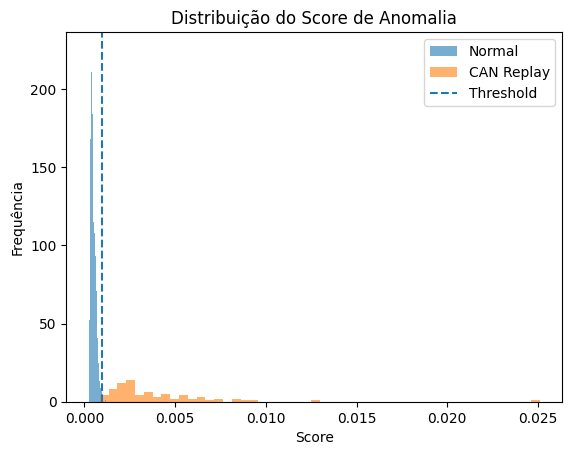

In [12]:
plt.figure()
plt.hist(scores[y_true['label'] == 'Normal'], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[y_true['label'] != 'Normal'], bins=50, alpha=0.6, label="CAN Replay")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.legend()
plt.title("Distribuição do Score de Anomalia")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.show()

# Train view

In [26]:
benign_idx = y_true_benign.index

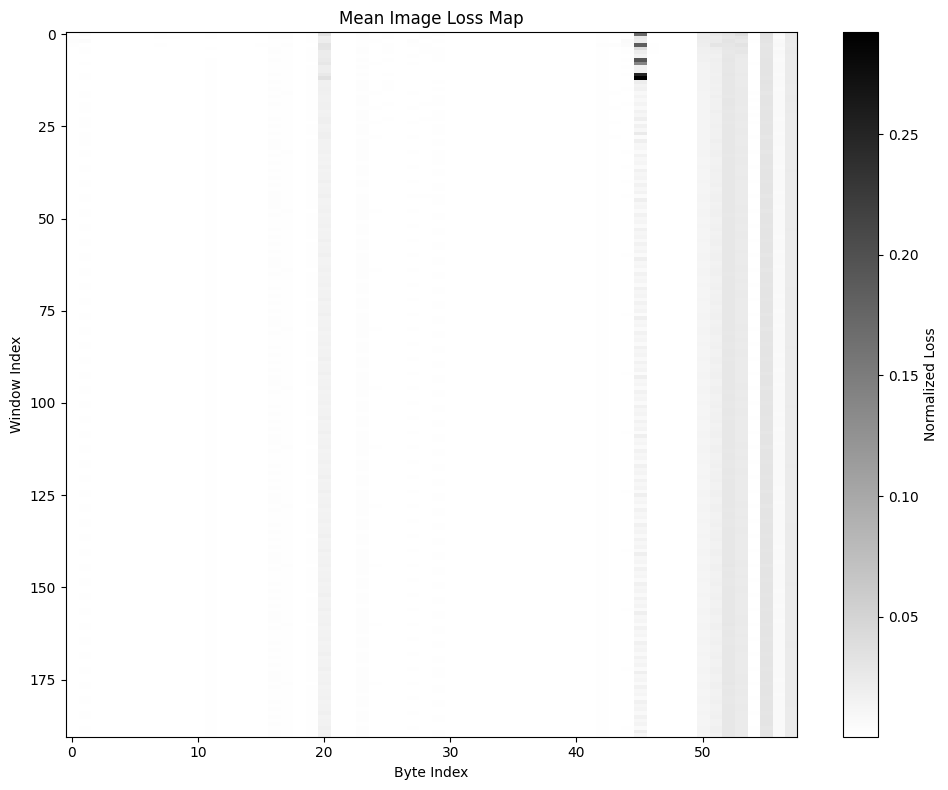

In [27]:
plot_img_loss(y_scores[benign_idx].mean(0))

In [ ]:
y_true[(y_true['label'] != 'Normal') & (y_true['scores'] < threshold)]

,label,start_idx,desc_windows,scores
10213,Replay,1585276713,"[Replay, Normal, Normal, Normal, Normal, Norma...",0.003415
45501,Replay,1585277606,"[Replay, Normal, Normal, Normal, Normal, Norma...",0.003506
48423,Replay,1585277673,"[Replay, Normal, Normal, Normal, Normal, Norma...",0.003544
49914,Replay,1585277694,"[Replay, Normal, Normal, Normal, Normal, Norma...",0.003517
55763,Replay,1585277799,"[Replay, Normal, Normal, Normal, Normal, Norma...",0.003384


In [44]:
threshold

np.float64(0.003630385966971)

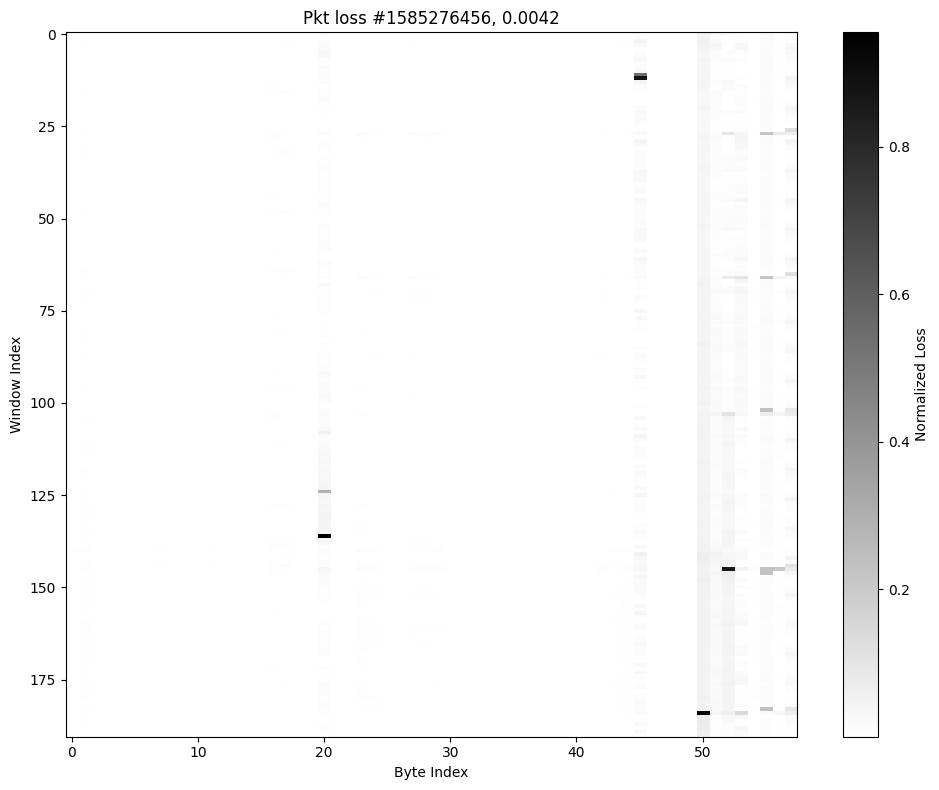

In [47]:
idx = y_true[(y_true['label'] == 'Normal') & (y_true['scores'] > threshold)].index[10]
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}, {y_true['scores'].iloc[idx]:.4f}')

# Sharp

In [14]:
T = 192
stride = 16
n_bytes = 58

In [15]:
from modeling.structure.factory import ModelingStructureFactory
from utils.get_device import get_device

device = get_device()
model = ModelingStructureFactory().get(config, logger, device)
model.compile()

/Users/mauriciosightman/Documents/Work/master/RABID/.venv/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [16]:
def score_no_reduction(X_flat):
    # X_flat: numpy array (batch, T*n_bytes)

    X_flat = torch.tensor(
        X_flat.reshape(T, n_bytes),
        dtype=torch.float32,
        device=device
    )

    X = X_flat.view(-1, T, n_bytes)

    x_in = X[:, :-1, :]
    x_true = X[:, 1:, :]

    with torch.no_grad():
        x_pred = model(x_in)

    error = (x_true - x_pred) ** 2

    return error.cpu().numpy()

In [17]:
X_train, y_train    = load_x(f'../data/autoeth-intrusion-dataset/processed/train_sliding-window_wsize_{T}_wstride_{stride}_n_58_AVTP')

In [18]:
X_train.shape

(56231, 192, 58)

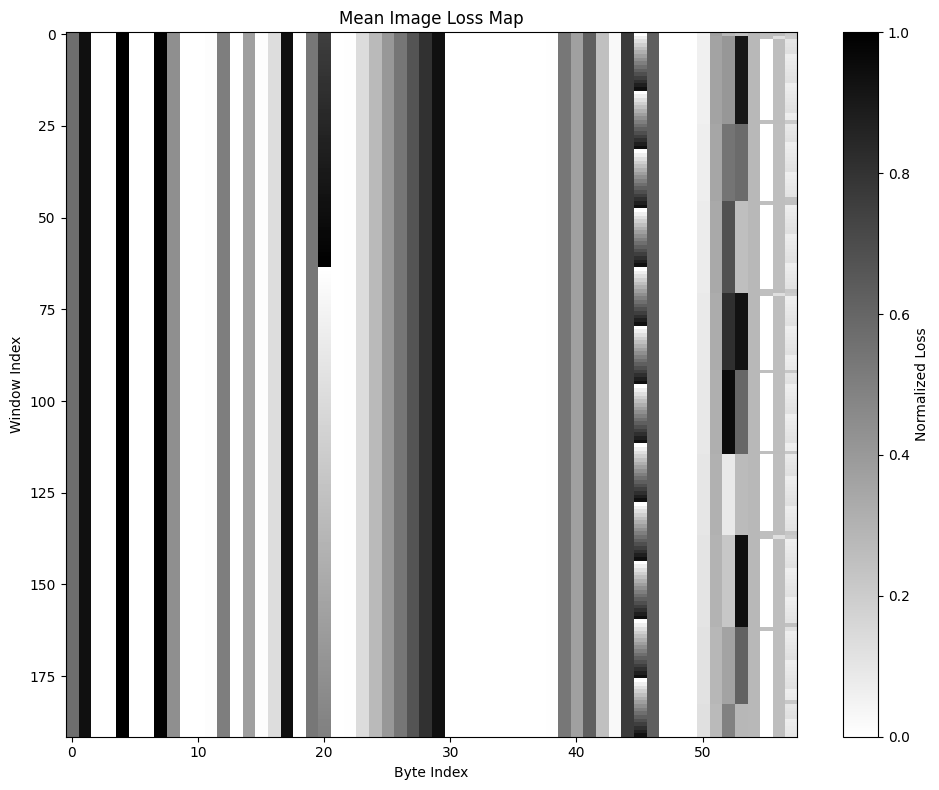

In [19]:
plot_img_loss(X_train[12])